# Speech Recognition for Fruit Words
### Using Hidden Markov Models (HMM) + Logistic Regression

**Pipeline overview:**
1. Load audio files organized by fruit label
2. Apply data augmentation (pitch shift, time stretch)
3. Extract MFCC + delta features from each audio file
4. Train one dedicated HMM per fruit word
5. Use HMM log-likelihood scores as features for Logistic Regression
6. Evaluate on a held-out test set
7. Predict a new audio file

> **Dataset:** 7 fruit words × 15 recordings each = 105 audio files  
> **Words:** apple, banana, orange, kiwi, lime, peach, pineapple

#### I have to thank  [Ashiq Nazir Bhat](https://www.kaggle.com/ashiqnazir) for his Notebook [HMM Speech Modelling and Training](https://www.kaggle.com/code/ashiqnazir/hmm-speech-modelling-and-training) that's helped me so much .

## Step 1 : Install & Import Libraries

In [18]:
pip install hmmlearn -q

Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
import numpy as np
import librosa
from librosa.feature import mfcc
from hmmlearn import hmm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

AUDIO_DIR = '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio'
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 2 : Explore the Dataset

Each subfolder = one fruit word label. We confirm the folder structure and count files.

In [20]:
word_labels = []
for dirname in sorted(os.listdir(AUDIO_DIR)):
    subfolder = os.path.join(AUDIO_DIR, dirname)
    if not os.path.isdir(subfolder):
        continue
    files = [f for f in os.listdir(subfolder) if f.endswith('.wav')]
    word_labels.append(dirname)
    print(f'  {dirname:12s} : {len(files)} files')

print(f'\nTotal classes : {len(word_labels)}')
print(f'Total files   : {len(word_labels) * 15}')

  apple        : 15 files
  banana       : 15 files
  kiwi         : 15 files
  lime         : 15 files
  orange       : 15 files
  peach        : 15 files
  pineapple    : 15 files

Total classes : 7
Total files   : 105


In [21]:
file_paths = []
file_labels = []

for label in word_labels:
    subfolder = os.path.join(AUDIO_DIR, label)
    for fname in os.listdir(subfolder):
        if fname.endswith('.wav'):
            file_paths.append(os.path.join(subfolder, fname))
            file_labels.append(label)

print(f'Total files collected: {len(file_paths)}')
print(f'Unique labels: {set(file_labels)}')

Total files collected: 105
Unique labels: {'kiwi', 'apple', 'lime', 'banana', 'orange', 'pineapple', 'peach'}


In [22]:
train_files, test_files, train_labels, test_labels = train_test_split(
    file_paths, file_labels,
    test_size=0.2,
    random_state=42,
    stratify=file_labels
)

print(f'Training files   : {len(train_files)}')
print(f'Test files       : {len(test_files)}')
from collections import Counter
print("Train distribution:", Counter(train_labels))
print("Test distribution :", Counter(test_labels))

Training files   : 84
Test files       : 21
Train distribution: Counter({'peach': 12, 'orange': 12, 'banana': 12, 'pineapple': 12, 'kiwi': 12, 'lime': 12, 'apple': 12})
Test distribution : Counter({'pineapple': 3, 'apple': 3, 'lime': 3, 'banana': 3, 'orange': 3, 'peach': 3, 'kiwi': 3})


## Step 3 : Data Augmentation

Each audio clip is turned into **4 versions** to increase training variety:

| Version | What changes |
|---------|-------------|
| Original | Unchanged |
| Pitch shift | Voice sounds higher (2 semitones up) |
| Slow stretch | Speech slowed to 80% speed |
| Fast stretch | Speech sped up to 120% speed |

This helps the model generalize across different speakers and speaking styles.

In [23]:
def augment_audio(audio, sr):
    """Return 4 augmented versions of an audio clip."""
    return [
        audio,                                                    # original
        librosa.effects.pitch_shift(audio, sr=sr, n_steps=2),    # higher pitch
        librosa.effects.time_stretch(audio, rate=0.8),           # slower
        librosa.effects.time_stretch(audio, rate=1.2),           # faster
    ]

print('augment_audio() defined , produces 4 versions per clip.')

augment_audio() defined , produces 4 versions per clip.


## Step 4 : Feature Extraction

For each audio file we extract:

- **15 MFCC coefficients** — describe the spectral shape of the sound at each time frame
- **15 delta (Δ) coefficients** — rate of change of the MFCCs over time (captures movement)

These are stacked into a **(n_frames × 30)** matrix per file.

> We apply augmentation here too, so each file contributes 4× more training frames.

In [24]:
def extract_features(audio, sr, n_mfcc=15):
    """Extract MFCC + delta features. Returns shape (n_frames, 2*n_mfcc)."""
    mfcc_feat  = mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)          # (n_mfcc, n_frames)
    delta_feat = librosa.feature.delta(mfcc_feat)               # (n_mfcc, n_frames)
    return np.vstack([mfcc_feat, delta_feat]).T                  # (n_frames, 2*n_mfcc)

### Quick EDA : MFCC Feature Matrix

Visualizing one fruit's features helps confirm the extraction worked correctly.

In [25]:
X_train_frames = []   
y_train_frames = []   

for fpath, label in zip(train_files, train_labels):
    audio, sr = librosa.load(fpath)
    for aug_audio in augment_audio(audio, sr):
        features = extract_features(aug_audio, sr)
        X_train_frames.append(features)
        y_train_frames.extend([label] * features.shape[0])

X_train_frames = np.vstack(X_train_frames)
y_train_frames = np.array(y_train_frames)

print(f'X_train_frames shape: {X_train_frames.shape}')
print(f'Total frames: {X_train_frames.shape[0]:,}')

X_train_frames shape: (8174, 30)
Total frames: 8,174


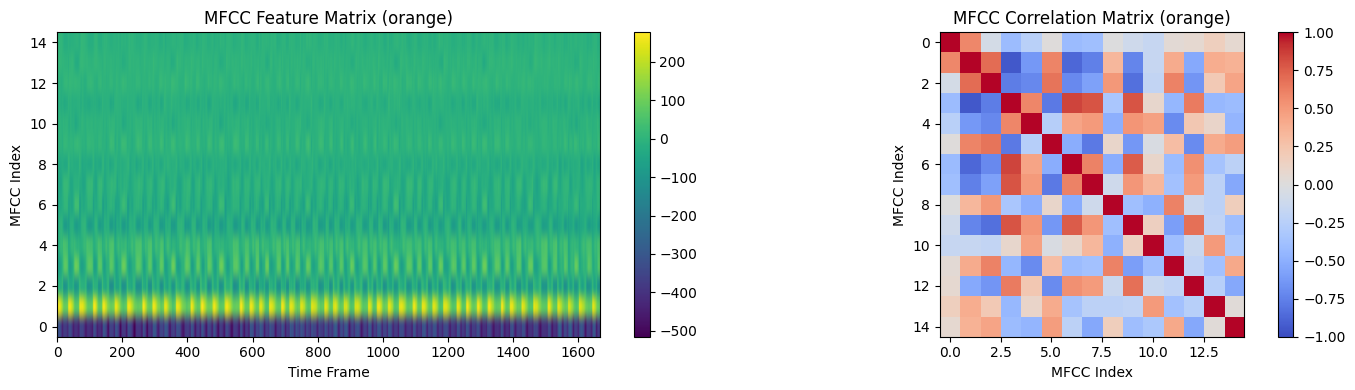

NaN values   : False
Inf values   : False


In [26]:
# Show MFCC heatmap for 'orange' frames only
orange_mask = y_train_frames == 'orange'
X_orange = X_train_frames[orange_mask][:, :15]  # first 15 = static MFCCs

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MFCC heatmap
axes[0].imshow(X_orange.T, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('MFCC Feature Matrix (orange)')
axes[0].set_xlabel('Time Frame')
axes[0].set_ylabel('MFCC Index')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Correlation matrix
corr = np.corrcoef(X_orange.T)
im = axes[1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('MFCC Correlation Matrix (orange)')
axes[1].set_xlabel('MFCC Index')
axes[1].set_ylabel('MFCC Index')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print(f'NaN values   : {np.isnan(X_train_frames).any()}')
print(f'Inf values   : {np.isinf(X_train_frames).any()}')

## Step 5 : Train One HMM per Fruit Word

A **Gaussian HMM** models the sequence of MFCC frames for each word.
We train 7 separate models — one per fruit , so each learns the unique
acoustic pattern of that specific word.

| Parameter | Value | Why |
|-----------|-------|-----|
| `n_components` | 10 | 10 hidden states ≈ 10 acoustic phases per word |
| `covariance_type` | diag | Faster, less prone to overfitting on small data |
| `n_iter` | 200 | Enough iterations for the model to converge |

In [27]:
hmm_models = {}
for label in word_labels:
    mask = y_train_frames == label
    label_features = X_train_frames[mask]
    model = hmm.GaussianHMM(
        n_components=10,
        covariance_type='diag',
        n_iter=200,
        random_state=42
    )
    model.fit(label_features)
    hmm_models[label] = model
    print(f'  Trained HMM for "{label}" on {label_features.shape[0]:,} frames')

print(f'\nTotal HMMs trained: {len(hmm_models)}')

  Trained HMM for "apple" on 892 frames
  Trained HMM for "banana" on 1,118 frames
  Trained HMM for "kiwi" on 884 frames
  Trained HMM for "lime" on 951 frames
  Trained HMM for "orange" on 1,668 frames
  Trained HMM for "peach" on 1,416 frames
  Trained HMM for "pineapple" on 1,245 frames

Total HMMs trained: 7


## Step 6 : Build the Score Feature Matrix

For every audio file we ask **all 7 HMMs** to score it.
This produces a **7-number vector** per file , one log-likelihood score per HMM.

```
audio file  ->  [score_apple, score_banana, score_orange, score_kiwi, score_lime, score_peach, score_pineapple]
```

These 7-score vectors become the input features for Logistic Regression.
This is much more informative than using a single score.

In [28]:

X_lr_train = []   
y_lr_train = []  

for fpath, label in zip(train_files, train_labels):
    audio, sr = librosa.load(fpath)
    features = extract_features(audio, sr)   # بدون augmentation
    scores = [hmm_models[l].score(features) for l in word_labels]
    X_lr_train.append(scores)
    y_lr_train.append(label)

X_lr_train = np.array(X_lr_train)   # shape: (num_train_files, 7)
y_lr_train = np.array(y_lr_train)

print(f'Score matrix shape : {X_lr_train.shape}')
print(f'  -> {X_lr_train.shape[0]} audio files × {X_lr_train.shape[1]} HMM scores')


Score matrix shape : (84, 7)
  -> 84 audio files × 7 HMM scores


## Step 7 : Train the Logistic Regression Classifier

Logistic Regression learns which pattern of 7 HMM scores corresponds to each word.
Class weights are balanced to handle any label imbalance.

In [29]:
# Scale scores to same range (required for Logistic Regression)
scaler = StandardScaler()
X_lr_train_scaled = scaler.fit_transform(X_lr_train)

# Compute balanced class weights
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_lr_train),
    y=y_lr_train
)
class_weights = dict(zip(np.unique(y_lr_train), cw))

classifier = LogisticRegression(
    max_iter=1000,
    class_weight=class_weights,
    random_state=42
)
classifier.fit(X_lr_train_scaled, y_lr_train)

print('Logistic Regression trained on HMM scores from training files.')
print(f'Classes learned: {list(classifier.classes_)}')


Logistic Regression trained on HMM scores from training files.
Classes learned: [np.str_('apple'), np.str_('banana'), np.str_('kiwi'), np.str_('lime'), np.str_('orange'), np.str_('peach'), np.str_('pineapple')]


## Step 8 : Evaluate on the Test Set

We measure performance only on the **held-out test files** — data the model has never seen.

In [30]:
X_lr_test = []
y_lr_test = []

for fpath, label in zip(test_files, test_labels):
    audio, sr = librosa.load(fpath)
    features = extract_features(audio, sr)
    scores = [hmm_models[l].score(features) for l in word_labels]
    X_lr_test.append(scores)
    y_lr_test.append(label)

X_lr_test = np.array(X_lr_test)
X_lr_test_scaled = scaler.transform(X_lr_test)


Classification Report (test set)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         3
      banana       1.00      1.00      1.00         3
        kiwi       1.00      1.00      1.00         3
        lime       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         3
       peach       1.00      1.00      1.00         3
   pineapple       1.00      1.00      1.00         3

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



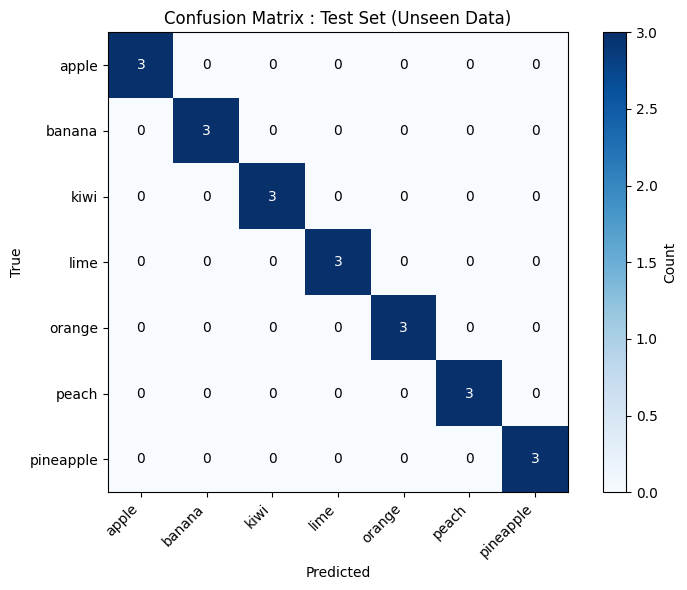

In [31]:
y_pred = classifier.predict(X_lr_test_scaled)

print('Classification Report (test set)\n')
print(classification_report(y_lr_test, y_pred, target_names=word_labels))

# Confusion matrix
cm = confusion_matrix(y_lr_test, y_pred, labels=word_labels)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Count')
plt.title('Confusion Matrix : Test Set (Unseen Data)')
plt.xticks(np.arange(len(word_labels)), word_labels, rotation=45, ha='right')
plt.yticks(np.arange(len(word_labels)), word_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(len(word_labels)):
    for j in range(len(word_labels)):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

## Step 9 : Predict a New Audio File

This is how you use the trained model on any new `.wav` recording.
The pipeline is: **load -> extract features -> score HMMs -> scale -> predict**.

In [32]:
test_files

['/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/pineapple/pineapple04.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/apple/apple02.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/lime/lime06.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/banana/banana05.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/orange/orange01.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/peach/peach13.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/lime/lime15.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/peach/peach15.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/orange/orange11.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/peach/peach04.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/apple/apple04.wav',
 '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/banana/banana06.wav',
 '/k

In [33]:
def predict_word(filepath):
    """
    Predict the spoken fruit word from a .wav file.
    Returns the predicted label string.
    """
    audio, sr = librosa.load(filepath)
    features  = extract_features(audio, sr)

    # Score against all trained HMMs
    scores = [hmm_models[l].score(features) for l in word_labels]

    # Scale using the same scaler fitted on training data
    scores_scaled = scaler.transform([scores])

    # Predict
    return classifier.predict(scores_scaled)[0]

In [34]:
# ── Test it ──────────────────────────────────────────────────────
test_file = '/kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/apple/apple02.wav'

predicted = predict_word(test_file)
true_word = test_file.split('/')[-2]   # folder name = true label

print(f'File      : {test_file}')
print(f'True word : {true_word}')
print(f'Predicted : {predicted}')
print(f'Correct   : {predicted == true_word}')

File      : /kaggle/input/datasets/ashiqnazir/spech-model-dataset/audio/apple/apple02.wav
True word : apple
Predicted : apple
Correct   : True
